# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.


La empresa Megaline ofrece dos Planes de suscripción: Surf y Ultimate. El departamento comercial quiere saber cuál de los planes genera más ingresos para poder ajustar el presupuesto de publicidad.
Para este análisis se cuenta con datos de 500 usuarios durante el año 2018, incluyendo minutos de llamadas, mensajes, datos de internet y cargos adicionales por exeder el limite de la tarifa.

El proceso comenzará con la carga y limpieza de los datos, eliminando duplicados y valores nulos de las tablas: users, calls, messages, internet y plans. Posteriormente se realizará un análisis estadístico descriptivo calculando métricas como la media, varianza y desviación estándar para entender el comportamiento de los usuarios en cada plan. A continuación se formularán y evaluarán dos pruebas de hipótesis especificas: 1. El ingreso promedio de los usuarios es igual para ambos planes. 2. El ingreso promedio es similar para la región Nueva York-Nueva Jersey comparado con otras regiones. Con un nivel de significancia de 5% para las pruebas de hipotesis.

Finalmente, con base en los resultados obtenidos, se presentará una conclusión que responda la pregunta central del análisis.

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
import seaborn as sns

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
users = pd.read_csv('datasets/megaline_users.csv')
calls = pd.read_csv('datasets/megaline_calls.csv')
messages = pd.read_csv('datasets/megaline_messages.csv')
internet = pd.read_csv('datasets/megaline_internet.csv')
plans = pd.read_csv('datasets/megaline_plans.csv')


## Preparar los datos

En esta sección se explorarán y limpiarán las cinco tablas del proyecto: tarifas, usuarios, llamadas, mensajes e internet. Para cada una se revisará la estructura general, se corregirán tipos de datos incorrectos o valores ausentes, y se agregarán columnas útiles si es necesario, con el fin de garantizar la calidad de los datos antes del análisis.

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
print("===Información general de la tabla Tarifa===")
plans.info()

===Información general de la tabla Tarifa===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas
print("===Muestra de los datos de la tabla Tarifa===")
print(plans)


===Muestra de los datos de la tabla Tarifa===
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


Analizando la tabla de tarifas no se encontraron datos con valores nulos ni datos duplicados. En esta tabla 'usd_monthly_pay' y 'usd_per_gb' son de tipo int64, almecenas monedas en dolares que son datos enteros mientras que  'usd_per_message' y 'usd_per_minute' son de tipo float64, tambien almacenan moneda pero en centavos, sin embargo, no considero necesario cambiar los tipos de datos ya que no afectaran cuando realicemos operaciones futuras. Tampoco es necesario agregar datos adicionales.

## Corregir datos

Para la tabla tarifa no se encontraron valores ausentes ni datos duplicados, al ser dos filas en la muestra de los datos se ve claramente.

In [5]:
# La tabla tarifa no requiere correcciones.

## Enriquecer los datos

Para la tabla tarifa no es necesario agregar nuevas columnas. No será necesario.

## Usuarios/as

In [6]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
print("===Información general de la tabla Usuarios===")
users.info()
print("===Duplicados en la tabla Usuarios===")
print(users.duplicated().sum())

===Información general de la tabla Usuarios===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
===Duplicados en la tabla Usuarios===
0


In [7]:
# Imprime una muestra de datos para usuarios
print("===Muestra de los datos de la tabla Usuarios===")
print(users.head())


===Muestra de los datos de la tabla Usuarios===
   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


Al revisar la información de la tabla Usuarios noto que 'churn_date’ contiene 466 valores nulos, lo que significa que esos usuarios tenían un plan activo cuando se extrajo la información. Los datos nulos no son un problema aquí. También note que 'reg_date' y  'churn_date’ son de tipo object, cuando deberían ser de tipo datetime. 


### Corregir los datos

Vamos a corregir el tipo de datos para las columnas 'reg_date' y'churn_date', que actualmente son de tipo object y se convertiran a tipo datetime.

In [8]:
# Convertir la columna 'reg_date' y la columna 'churn_date' a tipo datetime
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])
# Verificamos el cambio
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


### Enriquecer los datos

Para la tabla usuarios no es necesario agregar nuevas columnas. No será necesario.

## Llamadas

In [9]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
print("===Información general de la tabla Llamadas===")
calls.info()
print("===Duplicados en la tabla Llamadas===")
print(calls.duplicated().sum())
print("===Llamadas con duration == 0===")
print(calls[calls['duration'] == 0].shape[0])

===Información general de la tabla Llamadas===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
===Duplicados en la tabla Llamadas===
0
===Llamadas con duration == 0===
26834


In [10]:
# Imprime una muestra de datos para las llamadas
print("===Muestra de los datos de la tabla Llamadas===")
print(calls.head())



===Muestra de los datos de la tabla Llamadas===
         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


Observando la información de las columnas para la tabla llamadas, no encontré valores nulos ni filas duplicadas. Encontre errores de tipo de dato en la columna 'call_date' que debe ser de tipo datetime, y la columna 'duracion' donde en la descripción del proyecto nos dice que estos valores se redondean, asi que, el tipo int es mejor para estos datos. También encontre llamadas con duracion 0 minutos.

### Corregir los datos

Vamos a corregir el tipo de datos para las columnas 'call_date' a datetime y 'duration' a tipo int, además para 'duration' vamos a redondear hacia arriba. Finalmente estableceremos el valor minimo de 'duration' en 1.

In [11]:
# Convertir la columna 'call_date' a datetime y la columna 'duration a int
calls['call_date'] = pd.to_datetime(calls['call_date'])
# Primero redondeamos hacia arriba la columna 'duration'
calls['duration'] = np.ceil(calls['duration'])
calls['duration'] = calls['duration'].astype('int')
# Hacemos que el valor minimo de llamada sea 1 minuto
calls['duration'] = calls['duration'].clip(lower=1)
# Verificamos el cambio
calls.info()
print("===Llamadas con duration == 0===")
print(calls[calls['duration'] == 0].shape[0])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 4.2+ MB
===Llamadas con duration == 0===
0


### Enriquecer los datos

Mas adelante en el proyecto se me pide calcular el uso por mes para cada usuario, asi que una columna 'mes' sera necesaria.

In [12]:
# Creamos la nueva columna 'mes'
calls['mes'] = calls['call_date'].dt.month

## Mensajes

In [13]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
print("===Información general de la tabla Mensajes===")
messages.info()
print("===Duplicados en la tabla Mensajes===")
print(messages.duplicated().sum())

===Información general de la tabla Mensajes===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
===Duplicados en la tabla Mensajes===
0


In [14]:
# Imprime una muestra de datos para los mensajes
print("===Muestra de los datos de la tabla Mensajes===")
print(messages.head())

===Muestra de los datos de la tabla Mensajes===
         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


Observando la información de las columnas para la tabla mensajes, no encontré valores nulos y filas duplicadas. Encontre errores de tipo de dato en la columna 'message_date' que debe ser de tipo datetime.

### Corregir los datos

Vamos a corregir el tipo de datos para las columna 'message_date' a datetime.

In [15]:
# Convertir la columna 'message_date' a datetime
messages['message_date'] = pd.to_datetime(messages['message_date'])
# Verificamos el cambio
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enriquecer los datos

Al igual que en la tabla Usuarios vamos a necesitar una columna 'mes' para la tabla Mensajes y poder filtrar los datos en el análisis.


In [16]:
# Creamos la nueva columna 'mes'
messages['mes'] = messages['message_date'].dt.month

## Internet

In [17]:
# Imprime la información general/resumida sobre el DataFrame de internet
print("===Información general de la tabla Internet===")
internet.info()
print("===Duplicados en la tabla Internet===")
print(internet.duplicated().sum())

===Información general de la tabla Internet===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
===Duplicados en la tabla Internet===
0


In [18]:
# Imprime una muestra de datos para el tráfico de internet
print("===Muestra de los datos de la tabla Internet===")
print(internet.head())

===Muestra de los datos de la tabla Internet===
         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


Observando la información de las columnas para la tabla internet, no encontré valores nulos y filas duplicadas. Encontre errores de tipo de dato en la columna 'session_date' que debe ser de tipo datetime.

### Corregir los datos

Vamos a corregir el tipo de datos para las columna 'session_date' a datetime.

In [19]:
# Convertir la columna 'session_date' a datetime
internet['session_date'] = pd.to_datetime(internet['session_date'])
# Verificamos el cambio
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enriquecer los datos

Al igual que en las tablas anteriores vamos a necesitar una columna 'mes' para la tabla Internet y poder filtrar los datos en el análisis.


In [20]:
# Creamos la nueva columna 'mes'
internet['mes'] = internet['session_date'].dt.month

## Estudiar las condiciones de las tarifas

Megaline maneja dos planes: Surf y Ultimate. El plan surf incluye 500 minutos, 50 SMS y 15 GB de datos al mes, pagando 20 USD. Si el usuario excede se le cobrará extra, 3 centavos por minuto extra, 3 centavos por mensaje extra y 10 dólares por GB extra. El plan ultimate incluye 3000 minutos, 1000 SMS y 30 GB de datos al mes, pagando 70 USD. Si el usuario excede se le cobrará extra, 1 centavo por minuto extra, 1 centavo por mensaje extra y 7 dólares por GB extra. Es importante la siguiente condición para el tráfico web: si el usuario excede la tarifa, el uso extra se redondeará hacia arriba al siguiente GB. Por ejemplo si un usuario del plan Surf usa, digamos, 16,500 MB en un mes se le cobrarán los 17408 MB (17 GB), osea dos GB extra lo que son 20 dólares extra.

In [21]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
print(plans)


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Agregar datos por usuario

En esta sección se agruparán los datos de llamadas, mensajes e internet por usuario y mes para obtener un único registro por usuario por periodo. Se calculará el total de llamadas, minutos, mensajes y gigabytes consumidos mensualmente. Para el caso de los gigabytes sabemos que la empresa redondea hacia arriba al siguiente megabyte así que después de la suma convertiremos megas a gigas y redondeamos hacia arriba. Posteriormente se unirá todo en una sola tabla, luego uniremos los datos de la tabla tarifa y así poder realizar las operaciones de resta y multiplicación para calcular los ingresos y después formular las hipótesis.
 

In [22]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
llamadas_por_usuario = calls.groupby(['user_id', 'mes'])['id'].count().reset_index().rename(columns={'id': 'total_llamadas'})
# Imprimimos una mustra para coorroborar el resultado
print("===Muestra del total de llamadas por usuario===")
print(llamadas_por_usuario.head())

===Muestra del total de llamadas por usuario===
   user_id  mes  total_llamadas
0     1000   12              16
1     1001    8              27
2     1001    9              49
3     1001   10              65
4     1001   11              64


In [23]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
min_por_usuario = calls.groupby(['user_id', 'mes'])['duration'].sum().reset_index().rename(columns={'duration': 'minutos'})
# Imprimimos una mustra para coorroborar el resultado
print("===Muestra del total de minutos por usuario===")
print(min_por_usuario.head())

===Muestra del total de minutos por usuario===
   user_id  mes  minutos
0     1000   12      124
1     1001    8      187
2     1001    9      326
3     1001   10      411
4     1001   11      441


In [24]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
sms_por_usuario = messages.groupby(['user_id', 'mes'])['id'].count().reset_index().rename(columns={'id': 'total_sms'})
# Imprimimos una mustra para coorroborar el resultado
print("===Muestra del total de mensajes por usuario===")
print(sms_por_usuario.head())

===Muestra del total de mensajes por usuario===
   user_id  mes  total_sms
0     1000   12         11
1     1001    8         30
2     1001    9         44
3     1001   10         53
4     1001   11         36


In [25]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
gb_por_usuario = internet.groupby(['user_id', 'mes'])['mb_used'].sum().reset_index().rename(columns={'mb_used': 'gb_used'})
# Convertimos megas a gigas y redondeamos hacia arriba. 
gb_por_usuario['gb_used'] = (gb_por_usuario['gb_used']/1024)
gb_por_usuario['gb_used'] = np.ceil(gb_por_usuario['gb_used']).astype('int')
# Imprimimos una mustra para coorroborar el resultado
print("===Muestra del total de gigabites usados por usuario===")
print(gb_por_usuario.head())

===Muestra del total de gigabites usados por usuario===
   user_id  mes  gb_used
0     1000   12        2
1     1001    8        7
2     1001    9       14
3     1001   10       22
4     1001   11       19


Juntamos los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado. Pensando en que hay usuarios que hacen llamadas y no necesariamente mandan mensajes o navegan en Internet, nuestras tablas no son del mismo tamaño, entonces, a la hora de juntar usaremos la opción how='outer' de la función marge. Como los espacios vacíos se llenarán con NaN tendremos que reemplazar este valor por 0 para mantener la consistencia de los datos.
También agregaremos los datos de la tarifa a esta tabla para calcular los ingresos por usuario y en la segunda prueba de hipótesis se pide comparar regiones de estados, así que, es buen momento para agregar la columna 'city' de la tabla Usuarios.

In [26]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
consumo_por_usuario = llamadas_por_usuario.merge(min_por_usuario, on=['user_id', 'mes'], how='outer').merge(sms_por_usuario, on=['user_id', 'mes'], how='outer').merge(gb_por_usuario, on=['user_id', 'mes'], how='outer')
print("===Buscamos si existen valores ausentes===")
print(consumo_por_usuario.isna().sum())
#Reemplazamos los valores ausuentes con 0
consumo_por_usuario = consumo_por_usuario.fillna(0).astype('int')
print("===Coorroborasmos el cambio===")
print(consumo_por_usuario.isna().sum())
# Mostramos los datos
print("===Muestra del total de consumo por usuario===")
print(consumo_por_usuario.head())

===Buscamos si existen valores ausentes===
user_id             0
mes                 0
total_llamadas     35
minutos            35
total_sms         487
gb_used            16
dtype: int64
===Coorroborasmos el cambio===
user_id           0
mes               0
total_llamadas    0
minutos           0
total_sms         0
gb_used           0
dtype: int64
===Muestra del total de consumo por usuario===
   user_id  mes  total_llamadas  minutos  total_sms  gb_used
0     1000   12              16      124         11        2
1     1001    8              27      187         30        7
2     1001    9              49      326         44       14
3     1001   10              65      411         53       22
4     1001   11              64      441         36       19


In [27]:
# Añade la información de la tarifa
# Agregamos la columna plan de cada usuario y city
consumo_por_usuario = consumo_por_usuario.merge(users[['user_id', 'plan', 'city']], on='user_id')
# Juntamos los datos de la tarifa y eliminamos la columna sobrante
consumo_por_usuario = consumo_por_usuario.merge(plans, left_on='plan', right_on='plan_name').drop(columns='plan_name')
print("===Muestra del total de consumo por usuario===")
print(consumo_por_usuario.head())

===Muestra del total de consumo por usuario===
   user_id  mes  total_llamadas  minutos  total_sms  gb_used      plan  \
0     1000   12              16      124         11        2  ultimate   
1     1001    8              27      187         30        7      surf   
2     1001    9              49      326         44       14      surf   
3     1001   10              65      411         53       22      surf   
4     1001   11              64      441         36       19      surf   

                                    city  messages_included  \
0  Atlanta-Sandy Springs-Roswell, GA MSA               1000   
1        Seattle-Tacoma-Bellevue, WA MSA                 50   
2        Seattle-Tacoma-Bellevue, WA MSA                 50   
3        Seattle-Tacoma-Bellevue, WA MSA                 50   
4        Seattle-Tacoma-Bellevue, WA MSA                 50   

   mb_per_month_included  minutes_included  usd_monthly_pay  usd_per_gb  \
0                  30720              3000            

Se calcularán los ingresos mensuales por usuario. Para cada concepto (llamadas, mensajes y datos), determinaremos si el usuario excedió el límite incluido en su plan si es asi se sumará el cargo extra.

In [28]:
# Calcula el ingreso mensual para cada usuario
consumo_por_usuario['usd_extra_por_llamadas'] = np.maximum(0,  consumo_por_usuario['minutos'] - consumo_por_usuario['minutes_included'])*consumo_por_usuario['usd_per_minute']
consumo_por_usuario['usd_extra_por_mensajes'] = np.maximum(0,  consumo_por_usuario['total_sms'] - consumo_por_usuario['messages_included'])*consumo_por_usuario['usd_per_message']
consumo_por_usuario['usd_extra_por_gb_usados'] = np.maximum(0,  consumo_por_usuario['gb_used'] - (consumo_por_usuario['mb_per_month_included'])//1024)*consumo_por_usuario['usd_per_gb']
consumo_por_usuario['usd_total_mensual'] = consumo_por_usuario['usd_monthly_pay'] + consumo_por_usuario['usd_extra_por_llamadas'] + consumo_por_usuario['usd_extra_por_mensajes'] + consumo_por_usuario['usd_extra_por_gb_usados']

In [29]:
print("===Muestra del total de consumo por usuario===")
print(consumo_por_usuario.head())

===Muestra del total de consumo por usuario===
   user_id  mes  total_llamadas  minutos  total_sms  gb_used      plan  \
0     1000   12              16      124         11        2  ultimate   
1     1001    8              27      187         30        7      surf   
2     1001    9              49      326         44       14      surf   
3     1001   10              65      411         53       22      surf   
4     1001   11              64      441         36       19      surf   

                                    city  messages_included  \
0  Atlanta-Sandy Springs-Roswell, GA MSA               1000   
1        Seattle-Tacoma-Bellevue, WA MSA                 50   
2        Seattle-Tacoma-Bellevue, WA MSA                 50   
3        Seattle-Tacoma-Bellevue, WA MSA                 50   
4        Seattle-Tacoma-Bellevue, WA MSA                 50   

   mb_per_month_included  minutes_included  usd_monthly_pay  usd_per_gb  \
0                  30720              3000            

## Estudia el comportamiento de usuario

Se analiza el comportamiento de los usuarios de cada plan (Surf y Ultimate). Para cada variable (minutos, mensajes y gigabytes) se calcularan estadísticas descriptivas como la media, varianza y desviación estándar. Además se graficaran histogramas para visualizar la distribución y diagramas de caja para comparar el comportamiento de los datos en cada plan de forma mensual, también un grafico de barrar para comparar la duración promedio de llamadas para cada plan y por cada mes.

### Llamadas

===Duración promedio de los planes surf y ultimate por mes===
           surf    ultimate
mes                        
1    209.000000  200.250000
2    304.555556  414.142857
3    338.565217  313.666667
4    360.720000  345.333333
5    410.558442  417.862069
6    442.577320  380.978723
7    462.107438  438.406780
8    421.500000  433.507042
9    425.582474  449.627907
10   441.502110  463.500000
11   434.653710  457.606299
12   486.481132  471.860927


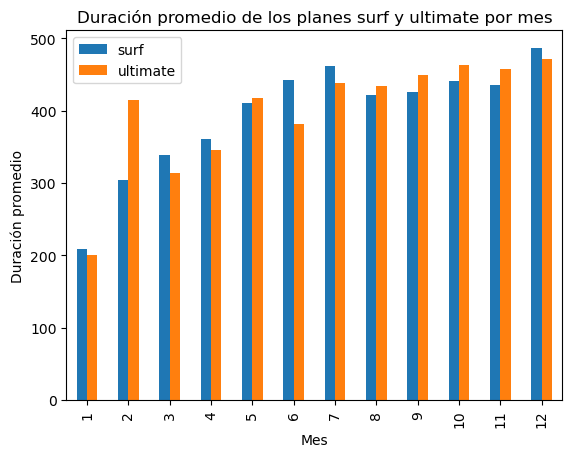

In [30]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
promedios_llamadas = consumo_por_usuario.groupby(['plan', 'mes'])['minutos'].mean()

llamadas_surf_mean = promedios_llamadas.loc['surf']
llamadas_ultimate_mean = promedios_llamadas.loc['ultimate']

duracion_promedio = pd.concat([llamadas_surf_mean, llamadas_ultimate_mean], axis = 1)
duracion_promedio.columns = ['surf','ultimate']

print("===Duración promedio de los planes surf y ultimate por mes===")
print(duracion_promedio)

duracion_promedio.plot(kind='bar',
                       title = 'Duración promedio de los planes surf y ultimate por mes',
                       xlabel = 'Mes',
                       ylabel = 'Duración promedio'
                      )
plt.show()

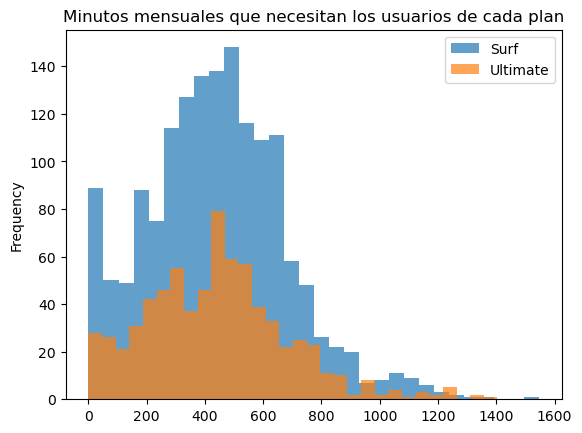

In [31]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
minutos_surf = consumo_por_usuario[consumo_por_usuario['plan'] == 'surf']['minutos']
minutos_ultimate = consumo_por_usuario[consumo_por_usuario['plan'] == 'ultimate']['minutos']
minutos_surf.plot(kind='hist', 
                  bins=30, 
                  title='Minutos mensuales que necesitan los usuarios de cada plan',
                  xlabel='Minutos',
                  alpha=0.7
                 )
minutos_ultimate.plot(kind='hist', bins=30, alpha=0.7)
plt.legend(['Surf', 'Ultimate'])

plt.show()


Se calculará la media, la varianza y la desviación estandar de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas. Y un diagrama de caja para comparar los datos visualmente.

In [32]:
# Calcula la media y la varianza de la duración mensual de llamadas.
varianza_llamadas = consumo_por_usuario.groupby(['plan', 'mes'])['minutos'].var()

print("===Calculos de la duración mensual===")
print("Media: \n", promedios_llamadas)
print("Varianza: \n", varianza_llamadas)

===Calculos de la duración mensual===
Media: 
 plan      mes
surf      1      209.000000
          2      304.555556
          3      338.565217
          4      360.720000
          5      410.558442
          6      442.577320
          7      462.107438
          8      421.500000
          9      425.582474
          10     441.502110
          11     434.653710
          12     486.481132
ultimate  1      200.250000
          2      414.142857
          3      313.666667
          4      345.333333
          5      417.862069
          6      380.978723
          7      438.406780
          8      433.507042
          9      449.627907
          10     463.500000
          11     457.606299
          12     471.860927
Name: minutos, dtype: float64
Varianza: 
 plan      mes
surf      1      16562.000000
          2      53925.777778
          3      37166.166008
          4      52940.164898
          5      62903.328776
          6      47635.225730
          7      64238.213361
 

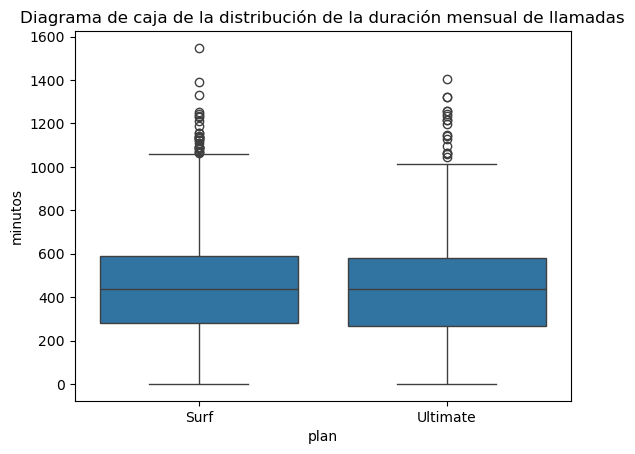

In [33]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
duracion_mensual = pd.DataFrame({'plan': ['Surf']*len(minutos_surf) + ['Ultimate']*len(minutos_ultimate), 'minutos': list(minutos_surf) + list(minutos_ultimate)})
sns.boxplot(x='plan', y='minutos', data=duracion_mensual)
plt.title('Diagrama de caja de la distribución de la duración mensual de llamadas')
plt.show()

El análisis de las llamadas muestra que los usuarios de ambos planes tienen patrones de uso muy similares. La duración promedio mensual de las llamadas aumenta gradualmente a lo largo del año en ambos planes, alcanzando sus valores más altos durante los últimos meses.

Las medias mensuales son muy parecidas entre Surf (394.82 minutos) y Ultimate (398.90 minutos), y las varianzas obtenidas son elevadas en ambos planes, lo que indica una gran dispersión en el tiempo de llamadas consumido por los usuarios. Sin embargo, en algunos meses se observan diferencias más notables; por ejemplo, en febrero los usuarios de Ultimate registraron un promedio de 414 minutos frente a 305 minutos en Surf.

El histograma muestra distribuciones similares para ambos planes, concentradas principalmente entre 300 y 700 minutos mensuales, con una ligera cola hacia valores altos. El diagrama de caja muestra rangos intercuartílicos similares y la presencia de valores atípicos en ambos grupos.


### Mensajes

===Mensajes promedio de los planes surf y ultimate por mes===
          surf   ultimate
mes                      
1    10.500000  15.500000
2    12.000000  21.571429
3    15.260870  20.250000
4    17.400000  22.047619
5    24.012987  32.103448
6    25.298969  29.340426
7    27.033058  32.830508
8    28.777778  38.478873
9    30.762887  37.895349
10   33.839662  39.443396
11   32.385159  38.606299
12   38.600629  45.006623


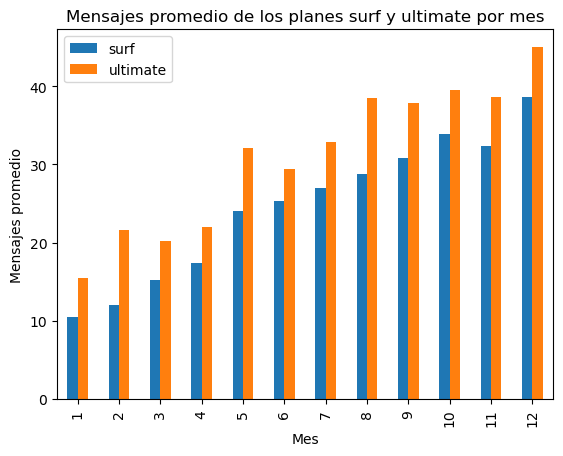

In [34]:
# Compara el promedio de mensajes por cada plan y por cada mes.
promedios_sms = consumo_por_usuario.groupby(['plan', 'mes'])['total_sms'].mean()

sms_surf_mean = promedios_sms.loc['surf']
sms_ultimate_mean = promedios_sms.loc['ultimate']

sms_promedio = pd.concat([sms_surf_mean, sms_ultimate_mean], axis = 1)
sms_promedio.columns = ['surf','ultimate']

print("===Mensajes promedio de los planes surf y ultimate por mes===")
print(sms_promedio)

sms_promedio.plot(kind='bar',
                       title = 'Mensajes promedio de los planes surf y ultimate por mes',
                       xlabel = 'Mes',
                       ylabel = 'Mensajes promedio'
                      )
plt.show()

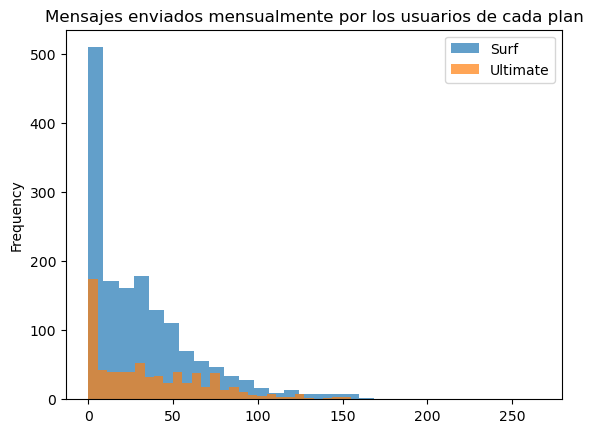

In [35]:

# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
sms_surf = consumo_por_usuario[consumo_por_usuario['plan'] == 'surf']['total_sms']
sms_ultimate = consumo_por_usuario[consumo_por_usuario['plan'] == 'ultimate']['total_sms']

sms_surf.plot(kind='hist', 
              bins=30, 
              title='Mensajes enviados mensualmente por los usuarios de cada plan',
              xlabel='Mensajes',
              alpha=0.7
             )
sms_ultimate.plot(kind='hist', bins=30, alpha=0.7)
plt.legend(['Surf', 'Ultimate'])

plt.show()


In [36]:
# Calcula la media y la varianza de mensajes que envian cada mes los usuarios de cada plan.
varianza_sms = consumo_por_usuario.groupby(['plan', 'mes'])['total_sms'].var()

print("===Calculos de los mesnajes mensuales===")
print("Media: \n", promedios_sms)
print("Varianza: \n", varianza_sms)

===Calculos de los mesnajes mensuales===
Media: 
 plan      mes
surf      1      10.500000
          2      12.000000
          3      15.260870
          4      17.400000
          5      24.012987
          6      25.298969
          7      27.033058
          8      28.777778
          9      30.762887
          10     33.839662
          11     32.385159
          12     38.600629
ultimate  1      15.500000
          2      21.571429
          3      20.250000
          4      22.047619
          5      32.103448
          6      29.340426
          7      32.830508
          8      38.478873
          9      37.895349
          10     39.443396
          11     38.606299
          12     45.006623
Name: total_sms, dtype: float64
Varianza: 
 plan      mes
surf      1       220.500000
          2       386.000000
          3       346.565217
          4       501.591837
          5       847.197198
          6       914.920103
          7       923.915565
          8      1029.51552

           count       mean        std  min  25%   50%   75%    max
plan                                                               
Surf      1573.0  31.159568  33.566717  0.0  3.0  24.0  47.0  266.0
Ultimate   720.0  37.551389  34.767179  0.0  7.0  30.0  61.0  166.0


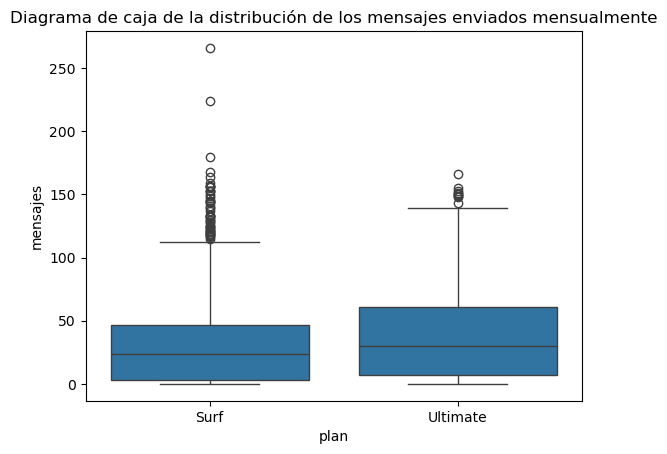

In [37]:
# Traza un diagrama de caja para visualizar la distribución de los mensajes enviados por mes
sms_por_mes = pd.DataFrame({'plan': ['Surf']*len(sms_surf) + ['Ultimate']*len(sms_ultimate), 'mensajes': list(sms_surf) + list(sms_ultimate)})

print(sms_por_mes.groupby('plan')['mensajes'].describe())
sns.boxplot(x='plan', y='mensajes', data=sms_por_mes)
plt.title('Diagrama de caja de la distribución de los mensajes enviados mensualmente')
plt.show()



A lo largo de todos los meses, los usuarios del plan Ultimate envían en promedio más mensajes que los usuarios del plan Surf, y ambos planes presentan una tendencia creciente en el uso de SMS conforme avanza el año.

Las medias generales confirman esta diferencia, con aproximadamente 37.6 mensajes mensuales para Ultimate frente a 31.2 para Surf. Además, el diagrama de caja muestra que la mediana y el rango intercuartílico de Ultimate son mayores, lo que indica que sus usuarios suelen utilizar más este servicio de forma habitual.

La dispersión de los datos es considerable en ambos planes, con desviaciones estándar de 34.8 mensajes para Ultimate y 33.6 para Surf, valores cercanos a sus respectivas medias. Esto indica que existe una gran variabilidad en la cantidad de mensajes enviados por los usuarios.  En el histograma vemos que los datos están sesgados a la derecha, muchos usuarios envían pocos mensajes, pero hay una cola larga hacia valores altos.

Desde una perspectiva de negocio, el incremento gradual del uso de SMS a lo largo del año sugiere un aumento en la actividad de los clientes. Además, los usuarios con consumos elevados podrían superar los límites incluidos en sus planes, especialmente en Surf, lo que podría traducirse en ingresos adicionales para Megaline.

### Internet

===Promedio de tráfico de Internet de los planes surf y ultimate por mes===
          surf   ultimate
mes                      
1     5.000000   7.250000
2    12.222222  17.285714
3    13.565217  18.416667
4    12.220000  16.333333
5    14.116883  16.862069
6    15.484536  15.425532
7    16.876033  16.491525
8    16.882716  17.845070
9    16.690722  17.011628
10   17.409283  17.716981
11   16.431095  17.118110
12   18.238994  18.397351


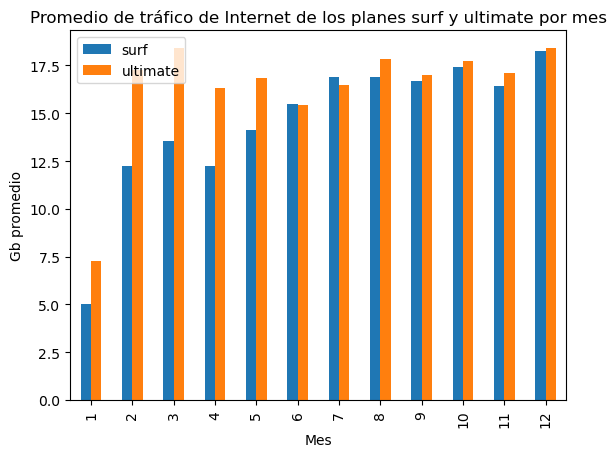

In [38]:
# Compara el promedio de tráfico de Internet por cada plan y por cada mes.
promedios_gb = consumo_por_usuario.groupby(['plan', 'mes'])['gb_used'].mean()

gb_surf_mean = promedios_gb.loc['surf']
gb_ultimate_mean = promedios_gb.loc['ultimate']

gb_promedio = pd.concat([gb_surf_mean, gb_ultimate_mean], axis = 1)
gb_promedio.columns = ['surf','ultimate']

print("===Promedio de tráfico de Internet de los planes surf y ultimate por mes===")
print(gb_promedio)

gb_promedio.plot(kind='bar',
                       title = 'Promedio de tráfico de Internet de los planes surf y ultimate por mes',
                       xlabel = 'Mes',
                       ylabel = 'Gb promedio'
                      )
plt.show()

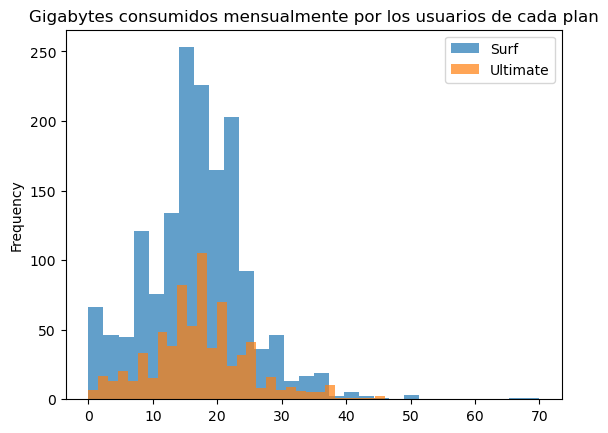

In [39]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
gb_surf = consumo_por_usuario[consumo_por_usuario['plan'] == 'surf']['gb_used']
gb_ultimate = consumo_por_usuario[consumo_por_usuario['plan'] == 'ultimate']['gb_used']

gb_surf.plot(kind='hist', 
              bins=30, 
              title='Gigabytes consumidos mensualmente por los usuarios de cada plan',
              xlabel='Gigabytes',
              alpha=0.7
             )
gb_ultimate.plot(kind='hist', bins=30, alpha=0.7)
plt.legend(['Surf', 'Ultimate'])

plt.show()


In [40]:
# Calcula la media y la varianza de tráfico de Internet consumido por usuarios por plan
varianza_gb = consumo_por_usuario.groupby(['plan', 'mes'])['gb_used'].var()

print("===Calculos de los gigas mensuales===")
print("Media: \n", promedios_gb)
print("Varianza: \n", varianza_gb)

===Calculos de los gigas mensuales===
Media: 
 plan      mes
surf      1       5.000000
          2      12.222222
          3      13.565217
          4      12.220000
          5      14.116883
          6      15.484536
          7      16.876033
          8      16.882716
          9      16.690722
          10     17.409283
          11     16.431095
          12     18.238994
ultimate  1       7.250000
          2      17.285714
          3      18.416667
          4      16.333333
          5      16.862069
          6      15.425532
          7      16.491525
          8      17.845070
          9      17.011628
          10     17.716981
          11     17.118110
          12     18.397351
Name: gb_used, dtype: float64
Varianza: 
 plan      mes
surf      1       18.000000
          2       41.444444
          3       63.984190
          4       56.215918
          5       58.183527
          6       47.752363
          7       61.476171
          8       71.420942
          9

           count       mean       std  min   25%   50%   75%   max
plan                                                              
Surf      1573.0  16.670693  7.847522  0.0  12.0  17.0  21.0  70.0
Ultimate   720.0  17.306944  7.670108  0.0  13.0  17.0  21.0  46.0


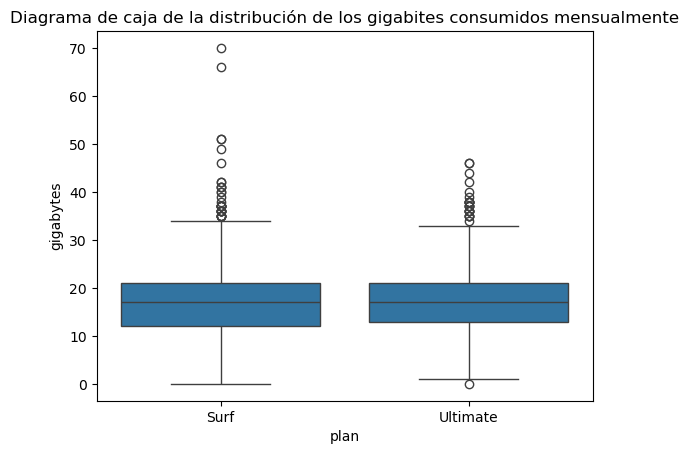

In [41]:
# Traza un diagrama de caja para visualizar la distribución de los gigabites consumidos por mes
gb_por_mes = pd.DataFrame({'plan': ['Surf']*len(gb_surf) + ['Ultimate']*len(gb_ultimate), 'gigabytes': list(gb_surf) + list(gb_ultimate)})
print(gb_por_mes.groupby('plan')['gigabytes'].describe())
sns.boxplot(x='plan', y='gigabytes', data=gb_por_mes)
plt.title('Diagrama de caja de la distribución de los gigabites consumidos mensualmente')
plt.show()


El consumo de datos móviles presenta un comportamiento muy similar entre los usuarios de los planes Surf y Ultimate. Aunque los usuarios de Ultimate consumen ligeramente más datos en promedio (17.3 GB frente a 16.7 GB en Surf), la diferencia es pequeña en comparación con la variabilidad observada en ambos grupos.

El gráfico de barras muestra una tendencia general de crecimiento en el consumo de internet a lo largo del año para ambos planes, estabilizándose alrededor de los 16 a 18 GB mensuales durante la segunda mitad del año. Esto sugiere un aumento progresivo en el uso de servicios móviles y aplicaciones que requieren conexión a internet.

Las medidas de dispersión también son muy similares. La desviación estándar es de aproximadamente 7.7 GB en ambos planes, lo que indica una variabilidad considerable en el consumo de datos entre usuarios. El diagrama de caja confirma esta similitud, ya que las medianas son idénticas (17 GB) y los rangos intercuartílicos prácticamente coinciden (entre 12-21 GB para Surf y 13-21 GB para Ultimate).

El histograma nos muestra que hay más usuarios cerca de la media con un ligero sesgo a la derecha, aunque existen algunos usuarios con consumos significativamente superiores al promedio, especialmente en el plan Surf, donde se observa el valor máximo más alto. Desde una perspectiva de negocio, resulta relevante que el consumo promedio del plan Surf supera los 15 GB incluidos en la tarifa, lo que sugiere que una parte de sus usuarios podría generar ingresos adicionales por excedentes de datos.
. El comportamiento de consumo de internet es muy similar para ambos planes con más usuarios en el plan surf solamente. El diagrama de caja nos muestra bastantes valores atípicos en ambos planes, especialmente en el plan surf donde existen valores que se alejan demasiado de la caja.

También se observa una mayor cantidad de registros para el plan Surf (1573 observaciones) en comparación con Ultimate (720 observaciones), lo que explica que las barras del histograma de Surf presenten frecuencias más elevadas. Esta diferencia refleja el tamaño de la muestra de cada plan y no necesariamente un mayor consumo de datos por usuario.

## Ingreso

Crearemos un histograma para comparar visualmente los ingresos de ambos planes. Después calcularemos la media, varianza y desviación estándar de ambos ingresos y veremos visualmente cómo se comportan estos valores en un diagrama de caja. Por último mostraremos la suma de ambos ingresos para comparar las cantidades.

===Promedio de ingresos de los planes surf y ultimate por mes===
          surf   ultimate
mes                      
1    20.000000  70.000000
2    34.456667  70.000000
3    45.996087  74.666667
4    40.832400  73.000000
5    47.834286  70.724138
6    49.455052  71.638298
7    62.904628  71.898305
8    64.118765  72.859155
9    58.444845  72.034884
10   65.618059  72.311321
11   58.185548  71.708661
12   70.783648  73.291391


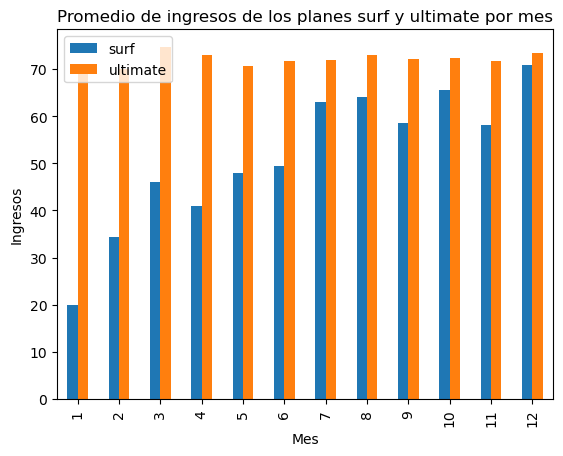

In [42]:
# Compara el promedio de tráfico de Internet por cada plan y por cada mes.
promedios_ingresos = consumo_por_usuario.groupby(['plan', 'mes'])['usd_total_mensual'].mean()

ingresos_surf_mean = promedios_ingresos.loc['surf']
ingresos_ultimate_mean = promedios_ingresos.loc['ultimate']

ingresos_promedio = pd.concat([ingresos_surf_mean, ingresos_ultimate_mean], axis = 1)
ingresos_promedio.columns = ['surf','ultimate']

print("===Promedio de ingresos de los planes surf y ultimate por mes===")
print(ingresos_promedio)

ingresos_promedio.plot(kind='bar',
                       title = 'Promedio de ingresos de los planes surf y ultimate por mes',
                       xlabel = 'Mes',
                       ylabel = 'Ingresos'
                      )
plt.show()

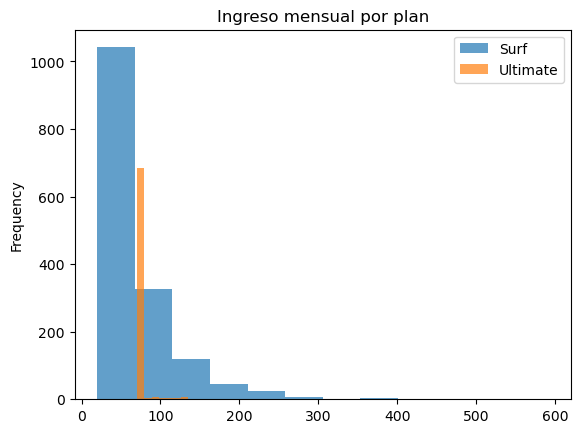

In [43]:
# Compara compara el ingreso mensual por plan
ingreso_surf = consumo_por_usuario[consumo_por_usuario['plan'] == 'surf']['usd_total_mensual']
ingreso_ultimate = consumo_por_usuario[consumo_por_usuario['plan'] == 'ultimate']['usd_total_mensual']

ingreso_surf.plot(kind='hist', 
              bins=12, 
              title='Ingreso mensual por plan',
              xlabel='Ingreso',
              alpha=0.7
             )
ingreso_ultimate.plot(kind='hist', bins=12, alpha=0.7)
plt.legend(['Surf', 'Ultimate'])

plt.show()


In [44]:
# Calcula la media y la varianza de ingresos generados por usuarios por plan
var_ingresos = consumo_por_usuario.groupby(['plan', 'mes'])['usd_total_mensual'].var()

print("===Calculos de los ingresos mensuales===")
print("Media: \n", promedios_ingresos)
print("Varianza: \n", var_ingresos)

===Calculos de los ingresos mensuales===
Media: 
 plan      mes
surf      1      20.000000
          2      34.456667
          3      45.996087
          4      40.832400
          5      47.834286
          6      49.455052
          7      62.904628
          8      64.118765
          9      58.444845
          10     65.618059
          11     58.185548
          12     70.783648
ultimate  1      70.000000
          2      70.000000
          3      74.666667
          4      73.000000
          5      70.724138
          6      71.638298
          7      71.898305
          8      72.859155
          9      72.034884
          10     72.311321
          11     71.708661
          12     73.291391
Name: usd_total_mensual, dtype: float64
Varianza: 
 plan      mes
surf      1         0.000000
          2       427.656900
          3      1513.463770
          4      1202.264219
          5      1975.616317
          6      1995.659948
          7      2955.029137
          8      35

           count       mean        std   min   25%    50%    75%     max
plan                                                                    
Surf      1573.0  60.899053  55.456000  20.0  20.0  40.42  80.72  591.27
Ultimate   720.0  72.313889  11.395108  70.0  70.0  70.00  70.00  182.00


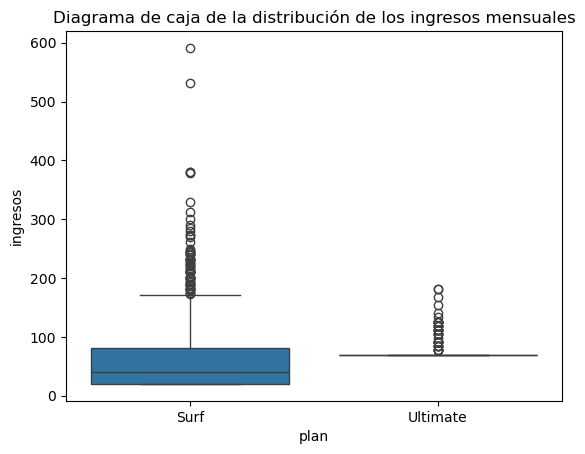

===Cantidad de usuarios por plan===
plan
surf        339
ultimate    161
Name: count, dtype: int64
===Ingresos generados en el año 2018 por el plan Surf===
95794.20999999999
===Ingresos generados en el año 2018 por el plan Ultimate===
52066.0


In [45]:
# Traza un diagrama de caja para visualizar la distribución del ingreso mensual
ingreso_por_mes = pd.DataFrame({'plan': ['Surf']*len(ingreso_surf) + ['Ultimate']*len(ingreso_ultimate), 'ingresos': list(ingreso_surf) + list(ingreso_ultimate)})
print(ingreso_por_mes.groupby('plan')['ingresos'].describe())
sns.boxplot(x='plan', y='ingresos', data=ingreso_por_mes)
plt.title('Diagrama de caja de la distribución de los ingresos mensuales')
plt.show()

print("===Cantidad de usuarios por plan===")
print(users['plan'].value_counts())

print("===Ingresos generados en el año 2018 por el plan Surf===")
print(ingreso_surf.sum())

print("===Ingresos generados en el año 2018 por el plan Ultimate===")
print(ingreso_ultimate.sum())



Los ingresos mensuales muestran diferencias importantes entre ambos planes. Aunque el plan Ultimate genera un ingreso promedio más alto por usuario (72.31 USD frente a 60.90 USD en Surf), sus ingresos son mucho más estables, ya que la mayoría de los usuarios pagan únicamente la tarifa base de 70 USD, como se observa en la mediana y los cuartiles del diagrama de caja.

Por otro lado, el plan Surf presenta una variabilidad considerablemente mayor (desviación estándar de 55.46 USD frente a 11.40 USD en Ultimate), lo que indica que muchos usuarios generan cargos adicionales al exceder los límites incluidos en el plan. Esto también explica la presencia de valores máximos mucho más altos y una distribución sesgada a la derecha.

Finalmente, aunque el ingreso promedio por usuario es mayor en Ultimate, el plan Surf generó más ingresos totales durante 2018 (95,794 USD frente a 52,066 USD). Sin embargo, esta diferencia está influenciada por la distribución de clientes entre los planes, ya que la muestra contiene 339 usuarios de Surf y 161 usuarios de Ultimate. Al contar con más del doble de usuarios, es esperable que Surf acumule una mayor cantidad de ingresos totales. Por esta razón, para determinar qué tarifa genera más ingresos por usuario y resulta potencialmente más rentable para la empresa, será necesario realizar una prueba estadística sobre los ingresos promedio de ambos planes.

## Prueba las hipótesis estadísticas

Para las pruebas de hipotesis nesecitaremos dos arreglos que se crearon anteriormente: ingresos_surf e ingresos_Ultimate. Para estos arreglos vamos a caulcular la varianza y compareremos para saber si son iguales.

H0 = El ingreso promedio de los usuarios de las tarifas Ultimate y Surf es igual.
H1 = El ingreso promedio de los usuarios de las tarifas Ultimate y Surf difiere
La prueba estadística que usaremos será ttest_ind para comparar dos grupos independiente entre si
Usaremos  alpha en 5%.

In [46]:

# Calculamos la varianza
print("Varianza Surf: ", ingreso_surf.var())
print("Varianza Ultimate: ", ingreso_ultimate.var())


Varianza Surf:  3075.3679024736775
Varianza Ultimate:  129.8484855509191


In [47]:
# Prueba las hipótesis
alpha = 0.05
# Para el calculo equal_var=False ya que las varianzas son diferentes
results = st.ttest_ind(ingreso_surf , ingreso_ultimate , equal_var=False)
print('valor p:', results.pvalue)

if (results.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p: 9.430219968963033e-15
Rechazamos la hipótesis nula


El valor p obtenido es significativamente menor que el nivel de significancia de 0.05, por lo que se rechaza la hipótesis nula. Esto indica que existe evidencia estadística suficiente para afirmar que los ingresos promedio de los usuarios de los planes Surf y Ultimate son diferentes.

En los datos analizados, el ingreso promedio mensual de los usuarios de Ultimate (72.31 USD) es superior al de los usuarios de Surf (60.90 USD). Desde una perspectiva de negocio, este resultado sugiere que los clientes del plan Ultimate generan mayores ingresos por usuario, información que puede ser útil al momento de definir estrategias de marketing y asignación de presupuesto publicitario.

Para las pruebas de hipotesis nesecitaremos dos arreglos que incluyan el ingreso mensual por usuario filtrado para la region de NY-NJ y otro que incluya las demas regiones. También vamos a calcular la variaza para saber que valor colocaremos en el parametro equal_var.

H0 = El ingreso promedio de los usuarios en el área de estados Nueva York-Nueva Jersey es igual al de los usuarios de otras regiones.
H1 = El ingreso promedio de los usuarios en el área de estados Nueva York-Nueva Jersey es diferente al de los usuarios de otras regiones.
La prueba estadística que usaremos será ttest_ind para comparar dos grupos independiente entre si
Usaremos  alpha en 5%.

In [48]:
# Calculamos la varianza
ingreso_ny_nj = consumo_por_usuario[consumo_por_usuario['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']['usd_total_mensual']
ingreso_other = consumo_por_usuario[consumo_por_usuario['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA']['usd_total_mensual']
varianza_ingreso_ny_nj = ingreso_ny_nj.var()
varianza_ingreso_other = ingreso_other.var()
print("Varianza NY-NJ: ", varianza_ingreso_ny_nj)
print("Varianza Otras regiones: ", varianza_ingreso_other)


Varianza NY-NJ:  1897.8185656738547
Varianza Otras regiones:  2229.6983584786176


In [49]:
# Prueba las hipótesis
alpha = 0.05
# Para el calculo equal_var=False ya que las varianzas son diferentes
results2 = st.ttest_ind(ingreso_ny_nj , ingreso_other , equal_var=False)
print('valor p:', results2.pvalue)

if (results2.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p: 0.034754837582215314
Rechazamos la hipótesis nula


In [50]:
#Mostramos el ingreso de la región Nueva York-Nueva Jersey y otras regiones
print("===Ingreso promedio generado en el año 2018 en la región Nueva York-Nueva Jersey===")
print(ingreso_ny_nj.mean())
print("===Ingreso promedio generado en el año 2018 otras regiones===")
print(ingreso_other.mean())

===Ingreso promedio generado en el año 2018 en la región Nueva York-Nueva Jersey===
60.08090185676392
===Ingreso promedio generado en el año 2018 otras regiones===
65.34953549060542


El valor p obtenido (0.0348) es menor que el nivel de significancia de 0.05, por lo que se rechaza la hipótesis nula. Esto indica que existe evidencia estadística suficiente para afirmar que los ingresos promedio de los usuarios del área Nueva York–Nueva Jersey y los de otras regiones son diferentes.

En los datos analizados, los usuarios de otras regiones presentan un ingreso promedio mensual mayor (65.22 USD) que los usuarios del área Nueva York–Nueva Jersey (59.92 USD). Desde una perspectiva de negocio, esto sugiere que la ubicación geográfica puede estar relacionada con diferencias en los ingresos generados por los clientes.

## Conclusión general

En este proyecto se analizó el comportamiento de 500 usuarios de Megaline durante 2018 con el objetivo de determinar cuál de las tarifas de prepago, Surf o Ultimate, genera mayores ingresos para la empresa.

1. Durante la preparación de los datos se realizaron varias transformaciones necesarias para garantizar la calidad del análisis. Las columnas de fecha fueron convertidas al tipo datetime para facilitar los cálculos mensuales. La duración de cada llamada se redondeó hacia arriba de acuerdo con las reglas de facturación de Megaline, además se estableció el límite inferior de duración de llamadas en 1 minuto y el consumo mensual de internet se convirtió de megabytes a gigabytes redondeando hacia arriba al final de cada mes. Posteriormente se calcularon las métricas mensuales por usuario (llamadas, minutos, mensajes e internet consumido) y se estimaron los ingresos mensuales considerando los límites y cargos adicionales de cada tarifa.

2. El análisis descriptivo mostró que los usuarios de ambos planes tienen un comportamiento similar en el uso de llamadas y datos móviles. Las diferencias más notables aparecieron en el envío de mensajes de texto, donde los usuarios de Ultimate enviaron más mensajes en promedio que los usuarios de Surf. Los histogramas y diagramas de caja revelaron distribuciones sesgadas y una presencia importante de valores atípicos, especialmente en el plan Surf, lo que indica que algunos usuarios exceden considerablemente los límites incluidos en su tarifa.

3. Respecto a los ingresos, el plan Ultimate presentó un ingreso promedio mensual superior (72.31 USD frente a 60.90 USD en Surf) y una desviación estándar mucho menor (11.40 USD frente a 55.46 USD). Esto indica que los ingresos generados por Ultimate son más estables y predecibles debido a su cuota mensual elevada y a los amplios límites incluidos en el plan. Por otro lado, los ingresos del plan Surf mostraron una variabilidad considerablemente mayor, ya que muchos usuarios exceden los límites de minutos, mensajes o datos y generan cargos adicionales. Aunque el ingreso promedio de Ultimate fue superior, el plan Surf generó mayores ingresos totales durante el período analizado (95,794 USD frente a 52,066 USD) debido a que cuenta con una mayor cantidad de usuarios y registros de actividad.

4. Para validar estos resultados se realizaron pruebas de hipótesis utilizando la prueba t para muestras independientes con un nivel de significación de 0.05. La primera prueba evaluó si los ingresos promedio de los planes Surf y Ultimate eran iguales. El valor p obtenido fue extremadamente pequeño (9.43 × 10e-15), por lo que se rechazó la hipótesis nula y se concluyó que existe una diferencia estadísticamente significativa entre los ingresos promedio de ambos planes.

5. La segunda prueba comparó los ingresos promedio de los usuarios de la región Nueva York–Nueva Jersey con los de otras regiones. El valor p obtenido fue 0.0348, menor que el nivel de significación establecido, por lo que también se rechazó la hipótesis nula. Esto indica que existe una diferencia estadísticamente significativa entre los ingresos promedio de los usuarios de Nueva York–Nueva Jersey y los usuarios del resto de las regiones, siendo el ingreso promedio de los usuarios de Nueva York–Nueva Jersey (59.92 USD) menor al de otras regiones (65.22 USD).

Supuestos y decisiones clave del análisis
- La duración de cada llamada se redondeó hacia arriba al minuto siguiente, siguiendo las reglas de facturación de Megaline.
- El consumo de internet se acumuló mensualmente por usuario y posteriormente se convirtió de megabytes a gigabytes redondeando hacia arriba.
- Los ingresos mensuales se calcularon sumando la tarifa base de cada plan más los cargos por excedentes de minutos, mensajes y datos cuando correspondía.
- Los meses sin actividad de un usuario fueron considerados con consumo igual a cero para evitar sobreestimar el uso promedio de los servicios.
- Los usuarios con fecha de cancelación (churn) solo aportaron información durante los meses en los que permanecieron activos dentro del conjunto de datos.
- Para las pruebas de hipótesis se utilizó un nivel de significación de α = 0.05. Además, se empleó equal_var=False en ttest_ind() debido a que las varianzas de los grupos comparados eran diferentes.

En conclusión, el plan Ultimate genera mayores ingresos promedio por usuario y presenta un comportamiento de ingresos más estable y predecible. Sin embargo, el plan Surf concentra una mayor cantidad de clientes y produjo mayores ingresos totales durante el período analizado, convirtiéndose en una fuente importante de ingresos para la empresa.

Por lo tanto, si el objetivo del departamento comercial es maximizar los ingresos totales, se recomienda priorizar la promoción del plan Surf. En cambio, si la estrategia busca aumentar el ingreso promedio por cliente y obtener ingresos más consistentes, la promoción del plan Ultimate sería la alternativa más adecuada.